In [ ]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# Zorgt ervoor dat de resultaten zoveel mogelijk hetzelfde blijven
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Fashion-MNIST heeft grijswaarden afbeeldingen van kledingstukken. Elke afbeelding is 28x28 en hoort bij een van de tien kleding categorie

Opgesplitst in:

- trainingsdata: hiermee leert het model
- validatiedata: hiermee controleren we tijdens training of het model goed generaliseert
- testdata: hiermee beoordelen we het eindresultaat


In [52]:
# Laad Fashion-MNIST dataset: 60.000 trainingsitems en 10.000 testitems
(train_images_full, train_labels_full), (test_images, test_labels) = fashion_mnist.load_data()

# Numerieke labels omzetten naar leesbare klassennamen
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Zet een vast aantal trainingsitems apart voor validatie
validation_size = 10_000

# Gebruik de eerste 50.000 items om het model te trainen
train_images = train_images_full[:-validation_size]
train_labels = train_labels_full[:-validation_size]

# Gebruik de laatste 10.000 items om het model tijdens training te valideren
validation_images = train_images_full[-validation_size:]
validation_labels = train_labels_full[-validation_size:]

In [53]:
# Verwacht: 50.000 afbeeldingen van 28x28 pixels en 50.000 labels.
print("Train images:", train_images.shape)
print("Train labels:", train_labels.shape)

# Verwacht: 10.000 afbeeldingen van 28x28 pixels en 10.000 labels.
print("Validation images:", validation_images.shape)
print("Validation labels:", validation_labels.shape)

# Deze set wordt pas gebruikt voor de eindbeoordeling van het model.
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

# Controleer of alle labels binnen de verwachte klassen vallen: 0 t/m 9.
print("\nLaagste label:", train_labels.min())
print("Hoogste label:", train_labels.max())
print("Unieke labels:", np.unique(train_labels))

Train images: (50000, 28, 28)
Train labels: (50000,)
Validation images: (10000, 28, 28)
Validation labels: (10000,)
Test images: (10000, 28, 28)
Test labels: (10000,)

Laagste label: 0
Hoogste label: 9
Unieke labels: [0 1 2 3 4 5 6 7 8 9]


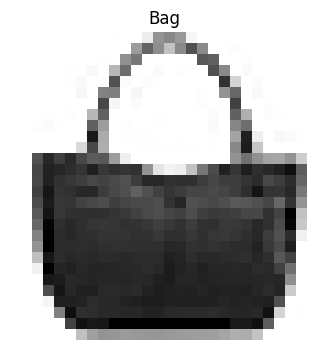

In [54]:
# Kies een voorbeeld afbeelding uit de trainingsset
example_index = 100     # min 0 - max 49999

# Maak een figuur en toon de afbeelding in zwart-wit
plt.figure(figsize=(4, 4))
# plt.imshow(train_images[example_index])
plt.imshow(train_images[example_index], cmap=plt.cm.binary)
# plt.imshow(train_images[example_index], cmap="gray")

# Toon het juiste label als titel
plt.title(class_names[train_labels[example_index]])

plt.axis("off")
plt.show()

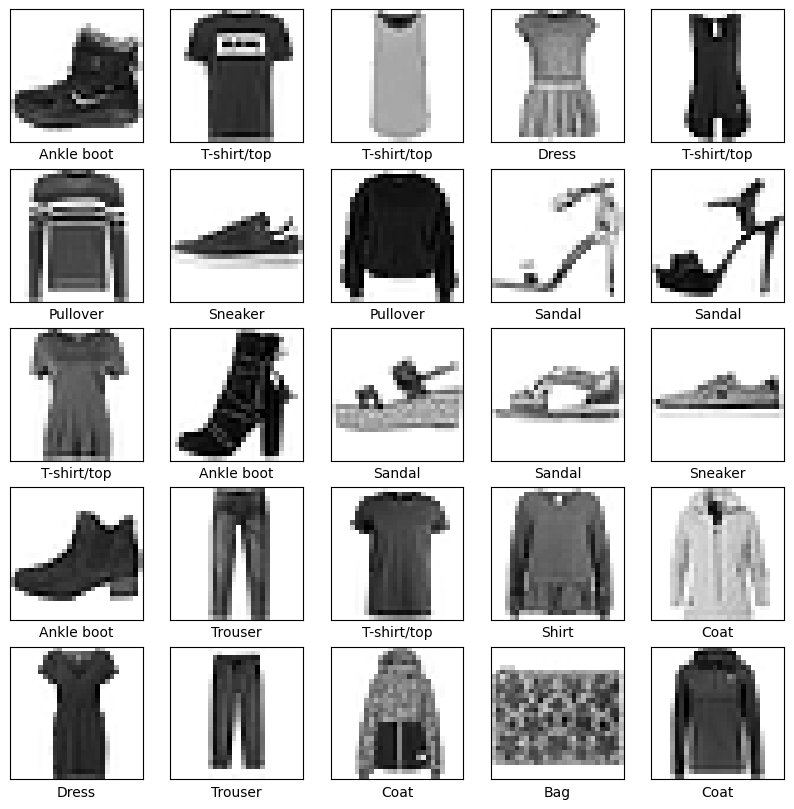

In [55]:
plt.figure(figsize=(10, 10))

for index in range(25):
    # Maak een 5x5 grid en plaats elke afbeelding op de juiste positie
    plt.subplot(5, 5, index + 1)

    # Verberg assen en grid, zodat alleen de afbeelding zichtbaar is
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Toon de afbeelding in grijswaarden met het juiste label eronder
    plt.imshow(train_images[index], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[index]])

plt.show()

In [56]:
def create_fashion_model(learning_rate=0.001):
    # Bouw een feedforward neural network voor 28x28 Fashion-MNIST afbeeldingen
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28)),

        # Zet elke afbeelding van 2D pixels naar 1D inputvector: 28 * 28 = 784 losse waarden
        tf.keras.layers.Flatten(),

        # Hidden layers: leren patronen zoals vormen, randen en kledingstructuren
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),

        # Output layer: 10 kansen, een per kledingcategorie
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    # Configureer hoe het model leert
    model.compile(
        # Sparse.. omdat labels getallen zijn
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        # Adam past de gewicht van het netwerk tijdens het training
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        # Laat zien hoeveel procent het accuraat is
        metrics=["accuracy"]
    )

    return model

In [57]:
# Maak een model dat direct traint op de originele pixelwaarden: 0 t/m 255
model_without_normalization = create_fashion_model()

# Train het model zonder normalisatie. Dus 0 t/m 255, niet 0 t/m 1
# De validatie set wordt gebruikt om tijdens training te controleren
history_without_normalization = model_without_normalization.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(validation_images, validation_labels),
    verbose=0       # geen process bar tonen
)

# Evalueer het getrainde model op de aparte testset.
# Deze data is nog niet gebruikt tijdens training of validatie.
test_loss_without_norm, test_accuracy_without_norm = model_without_normalization.evaluate(
    test_images,
    test_labels,
    verbose=0
)

# Prestaties zonder normalisatie
print(f"Test accuracy: {test_accuracy_without_norm:.4f}")
print(f"Test loss: {test_loss_without_norm:.4f}")
# Het model haalt 84,85% nauwkeurigheid en een loss van 0.4374.

# De loss blijft hoog omdat zekerheid meetelt:
# - Correct + hoge zekerheid (90%) → lage loss
# - Correct + lage zekerheid (51%) → hogere loss
# - Fout + hoge zekerheid (95%) → zeer hoge loss

Test accuracy: 0.8402
Test loss: 0.4707


In [58]:
# Normaliseer de trainingsdata: pixelwaarden gaan van 0-255 naar 0-1
train_images_norm = train_images.astype("float32") / 255.0

# Normaliseer de validatiedata op exact dezelfde manier
validation_images_norm = validation_images.astype("float32") / 255.0

# Normaliseer ook de testdata, zodat alle datasets dezelfde schaal gebruiken
test_images_norm = test_images.astype("float32") / 255.0

In [59]:
# Maak een nieuw model voor het experiment mét normalisatie
# Dit model start opnieuw met eigen gewichten, zodat de vergelijking eerlijk blijft
model_with_normalization = create_fashion_model()

# Train het model op genormaliseerde pixelwaarden: 0-1 in plaats van 0-255
history_with_normalization = model_with_normalization.fit(
    train_images_norm,
    train_labels,
    epochs=10,
    validation_data=(validation_images_norm, validation_labels),
    verbose=0
)

# Evalueer het model op de genormaliseerde testset
# Belangrijk: testdata moet dezelfde preprocessing krijgen als trainingsdata
test_loss_with_norm, test_accuracy_with_norm = model_with_normalization.evaluate(
    test_images_norm,
    test_labels,
    verbose=0
)

# Toon de eindscore van het model mét normalisatie
print(f"Test accuracy met normalisatie: {test_accuracy_with_norm:.4f}")
print(f"Test loss met normalisatie: {test_loss_with_norm:.4f}")

Test accuracy met normalisatie: 0.8742
Test loss met normalisatie: 0.3996


In [60]:
def create_experiment_model(hidden_layers, learning_rate=0.001, dropout_rate=0.0):
    # Bouw een flexibel model waarmee we verschillende netwerkconfiguraties kunnen testen
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Flatten()
    ])

    # Voeg per waarde in hidden_layers een Dense-layer toe
    # Voorbeeld: [128, 64] maakt twee lagen met 128 en 64 neuronen
    for units in hidden_layers:
        model.add(tf.keras.layers.Dense(units, activation="relu"))

        # Voeg optioneel Dropout toe om overfitting te beperken
        if dropout_rate > 0:
            model.add(tf.keras.layers.Dropout(dropout_rate))

    # Output layer: 10 kansen, één voor elke Fashion-MNIST klasse
    model.add(tf.keras.layers.Dense(10, activation="softmax"))

    # Configureer de loss, optimizer en metric voor classificatie
    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"]
    )

    return model

In [61]:
# Fashion-MNIST experimenten.
# We testen aantal hidden layers, aantal neuronen, learning rate, dropout, epochs en batch size.
experiments = [
    # Aantal hidden layers testen
    {"Experiment": "E01 0 lagen", "hidden_layers": [], "learning_rate": 0.001, "dropout_rate": 0.0, "epochs": 10, "batch_size": 32},
    {"Experiment": "E02 1 laag 16", "hidden_layers": [16], "learning_rate": 0.001, "dropout_rate": 0.0, "epochs": 10, "batch_size": 32},
    {"Experiment": "E03 1 laag 32", "hidden_layers": [32], "learning_rate": 0.001, "dropout_rate": 0.0, "epochs": 10, "batch_size": 32},
    {"Experiment": "E04 1 laag 64", "hidden_layers": [64], "learning_rate": 0.001, "dropout_rate": 0.0, "epochs": 10, "batch_size": 32},

    # Twee hidden layers testen
    {"Experiment": "E05 2 lagen 32-16", "hidden_layers": [32, 16], "learning_rate": 0.001, "dropout_rate": 0.0, "epochs": 10, "batch_size": 32},
    {"Experiment": "E06 2 lagen 64-32", "hidden_layers": [64, 32], "learning_rate": 0.001, "dropout_rate": 0.0, "epochs": 10, "batch_size": 32},
    {"Experiment": "E07 2 lagen 128-64", "hidden_layers": [128, 64], "learning_rate": 0.001, "dropout_rate": 0.0, "epochs": 10, "batch_size": 32},

    # Drie en vier hidden layers testen
    {"Experiment": "E08 3 lagen 32-16-8", "hidden_layers": [32, 16, 8], "learning_rate": 0.001, "dropout_rate": 0.0, "epochs": 10, "batch_size": 32},
    {"Experiment": "E09 3 lagen 64-32-16", "hidden_layers": [64, 32, 16], "learning_rate": 0.001, "dropout_rate": 0.0, "epochs": 10, "batch_size": 32},
    {"Experiment": "E10 4 lagen 64-32-16-8", "hidden_layers": [64, 32, 16, 8], "learning_rate": 0.001, "dropout_rate": 0.0, "epochs": 10, "batch_size": 32},

    # Learning rate testen met hetzelfde 2-laags model
    {"Experiment": "E11 LR 0.0005", "hidden_layers": [64, 32], "learning_rate": 0.0005, "dropout_rate": 0.0, "epochs": 10, "batch_size": 32},
    {"Experiment": "E12 LR 0.005", "hidden_layers": [64, 32], "learning_rate": 0.005, "dropout_rate": 0.0, "epochs": 10, "batch_size": 32},

    # Dropout testen met hetzelfde 2-laags model
    {"Experiment": "E13 Dropout 0.1", "hidden_layers": [64, 32], "learning_rate": 0.001, "dropout_rate": 0.1, "epochs": 10, "batch_size": 32},
    {"Experiment": "E14 Dropout 0.2", "hidden_layers": [64, 32], "learning_rate": 0.001, "dropout_rate": 0.2, "epochs": 10, "batch_size": 32},
    {"Experiment": "E15 Dropout 0.3", "hidden_layers": [64, 32], "learning_rate": 0.001, "dropout_rate": 0.3, "epochs": 10, "batch_size": 32},

    # Epochs testen
    {"Experiment": "E16 Epochs 5", "hidden_layers": [64, 32], "learning_rate": 0.001, "dropout_rate": 0.0, "epochs": 5, "batch_size": 32},
    {"Experiment": "E17 Epochs 15", "hidden_layers": [64, 32], "learning_rate": 0.001, "dropout_rate": 0.0, "epochs": 15, "batch_size": 32},

    # Batch size testen
    {"Experiment": "E18 Batch 16", "hidden_layers": [64, 32], "learning_rate": 0.001, "dropout_rate": 0.0, "epochs": 10, "batch_size": 16},
    {"Experiment": "E19 Batch 64", "hidden_layers": [64, 32], "learning_rate": 0.001, "dropout_rate": 0.0, "epochs": 10, "batch_size": 64}
]

# Alle experimentresultaten worden hier opgeslagen
experiment_results = []

for experiment in experiments:
    print("Experiment:", experiment["Experiment"])

    # Start elk experiment met een schoon model en dezelfde seed
    tf.keras.backend.clear_session()
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = create_experiment_model(
        hidden_layers=experiment["hidden_layers"],
        learning_rate=experiment["learning_rate"],
        dropout_rate=experiment["dropout_rate"]
    )

    # Train het model met de instellingen van dit experiment
    history = model.fit(
        train_images_norm,
        train_labels,
        epochs=experiment["epochs"],
        batch_size=experiment["batch_size"],
        validation_data=(validation_images_norm, validation_labels),
        verbose=0
    )

    # Test het model op de aparte testset
    test_loss, test_accuracy = model.evaluate(
        test_images_norm,
        test_labels,
        verbose=0
    )

    # Sla de resultaten op voor vergelijking
    experiment_results.append({
        "Experiment": experiment["Experiment"],
        "Hidden layers": str(experiment["hidden_layers"]),
        "Aantal hidden layers": len(experiment["hidden_layers"]),
        "Learning rate": experiment["learning_rate"],
        "Dropout": experiment["dropout_rate"],
        "Epochs": experiment["epochs"],
        "Batch size": experiment["batch_size"],
        "Validation accuracy": round(history.history["val_accuracy"][-1], 4),
        "Test accuracy": round(test_accuracy, 4),
        "Test loss": round(test_loss, 4)
    })

Experiment: E01 0 lagen
Experiment: E02 1 laag 16
Experiment: E03 1 laag 32
Experiment: E04 1 laag 64
Experiment: E05 2 lagen 32-16
Experiment: E06 2 lagen 64-32
Experiment: E07 2 lagen 128-64
Experiment: E08 3 lagen 32-16-8
Experiment: E09 3 lagen 64-32-16
Experiment: E10 4 lagen 64-32-16-8
Experiment: E11 LR 0.0005
Experiment: E12 LR 0.005
Experiment: E13 Dropout 0.1
Experiment: E14 Dropout 0.2
Experiment: E15 Dropout 0.3
Experiment: E16 Epochs 5
Experiment: E17 Epochs 15
Experiment: E18 Batch 16
Experiment: E19 Batch 64


In [62]:
# Resultaten in een tabel zetten en sorteren op hoogste test accuracy
results_table = pd.DataFrame(experiment_results)
results_table = results_table.sort_values(by="Test accuracy", ascending=False)

results_table

,Experiment,Hidden layers,Aantal hidden layers,Learning rate,Dropout,Epochs,Batch size,Validation accuracy,Test accuracy,Test loss
12,E13 Dropout 0.1,"[64, 32]",2,0.0010,0.1,10,32,0.8797,0.8741,0.3590
17,E18 Batch 16,"[64, 32]",2,0.0010,0.0,10,16,0.8778,0.8732,0.3816
13,E14 Dropout 0.2,"[64, 32]",2,0.0010,0.2,10,32,0.8773,0.8729,0.3636
9,E10 4 lagen 64-32-16-8,"[64, 32, 16, 8]",4,0.0010,0.0,10,32,0.8725,0.8702,0.3847
16,E17 Epochs 15,"[64, 32]",2,0.0010,0.0,15,32,0.8826,0.8694,0.4019
5,E06 2 lagen 64-32,"[64, 32]",2,0.0010,0.0,10,32,0.8774,0.8692,0.3918
18,E19 Batch 64,"[64, 32]",2,0.0010,0.0,10,64,0.8745,0.8690,0.3778
15,E16 Epochs 5,"[64, 32]",2,0.0010,0.0,5,32,0.8739,0.8672,0.3777
10,E11 LR 0.0005,"[64, 32]",2,0.0005,0.0,10,32,0.8767,0.8661,0.3811
6,E07 2 lagen 128-64,"[128, 64]",2,0.0010,0.0,10,32,0.8747,0.8649,0.4289


In [63]:
# Pak het eerste resultaat uit de gesorteerde tabel.
# Omdat results_table is gesorteerd op Test accuracy, staat het beste model bovenaan.
best_experiment = results_table.iloc[0]

# Toon de belangrijkste resultaten van het beste experiment
print("Beste experiment:", best_experiment["Experiment"])
print("Test accuracy:", best_experiment["Test accuracy"])
print("Test loss:", best_experiment["Test loss"])

Beste experiment: E13 Dropout 0.1
Test accuracy: 0.8741
Test loss: 0.359


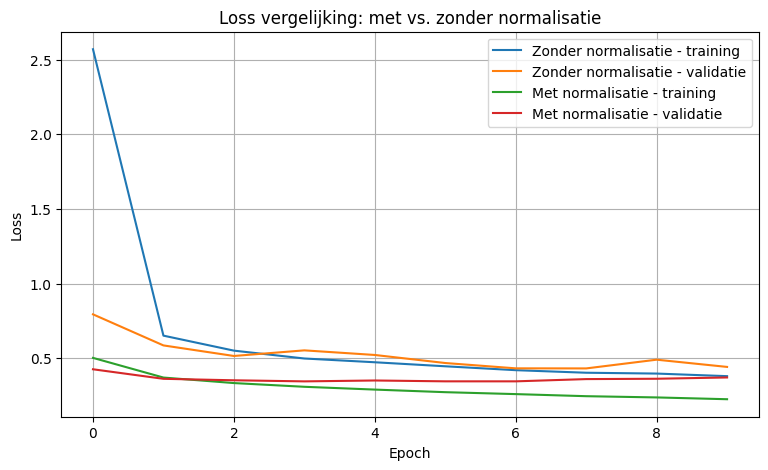

In [64]:
def plot_loss_comparison(history_without_norm, history_with_norm):
    # Vergelijk hoe de loss verandert tijdens training, met en zonder normalisatie
    plt.figure(figsize=(9, 5))

    # Loss van het model dat trainde op originele pixelwaarden: 0-255
    plt.plot(history_without_norm.history["loss"], label="Zonder normalisatie - training")
    plt.plot(history_without_norm.history["val_loss"], label="Zonder normalisatie - validatie")

    # Loss van het model dat trainde op genormaliseerde pixelwaarden: 0-1
    plt.plot(history_with_norm.history["loss"], label="Met normalisatie - training")
    plt.plot(history_with_norm.history["val_loss"], label="Met normalisatie - validatie")

    # Maak de grafiek leesbaar
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vergelijking: met vs. zonder normalisatie")
    plt.legend()
    plt.grid(True)
    plt.show()


# Vergelijk de trainingsgeschiedenis van beide modellen
plot_loss_comparison(history_without_normalization, history_with_normalization)

In [65]:
# Laat het getrainde model voor elke testafbeelding een kansverdeling voorspellen
# Output per afbeelding: 10 kansen, één per kledingcategorie
prediction_probabilities = model_with_normalization.predict(test_images_norm, verbose=0)

# Kies per afbeelding de klasse met de hoogste voorspelde kans
predicted_labels = prediction_probabilities.argmax(axis=1)

# Vergelijk de eerste voorspelling met het echte label
first_prediction = predicted_labels[0]
first_true_label = test_labels[0]

print("Eerste voorspelling:", first_prediction)
print("Echte label:", first_true_label)
print("Voorspelde klasse:", class_names[first_prediction])
print("Echte klasse:", class_names[first_true_label])

Eerste voorspelling: 9
Echte label: 9
Voorspelde klasse: Ankle boot
Echte klasse: Ankle boot


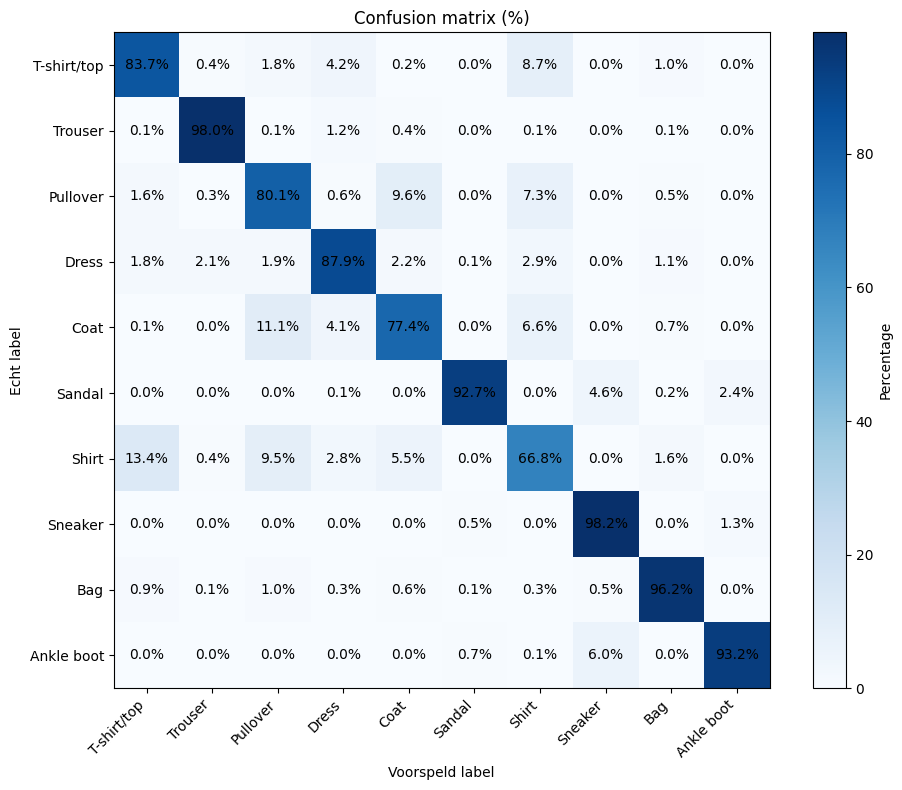

In [66]:
def plot_confusion_matrix_percent(true_labels, predicted_labels, classes):
    # Maak een confusion matrix: rijen = echte labels, kolommen = voorspelde labels
    matrix = tf.math.confusion_matrix(
        labels=true_labels,
        predictions=predicted_labels,
        num_classes=len(classes)
    ).numpy()

    # Zet aantallen om naar percentages per echte klasse
    # Hierdoor zie je per categorie hoeveel procent correct of fout is voorspeld
    row_totals = matrix.sum(axis=1, keepdims=True)
    matrix_percent = np.divide(
        matrix,
        row_totals,
        out=np.zeros_like(matrix, dtype="float32"),
        where=row_totals != 0
    ) * 100

    # Toon de matrix als heatmap
    plt.figure(figsize=(10, 8))
    plt.imshow(matrix_percent, cmap="Blues")
    plt.title("Confusion matrix (%)")
    plt.colorbar(label="Percentage")

    # Zet de klassennamen op de assen
    plt.xticks(np.arange(len(classes)), classes, rotation=45, ha="right")
    plt.yticks(np.arange(len(classes)), classes)

    # Toon het percentage in elk vakje
    for row in range(len(classes)):
        for column in range(len(classes)):
            plt.text(
                column,
                row,
                f"{matrix_percent[row, column]:.1f}%",
                ha="center",
                va="center",
                color="black"
            )

    plt.xlabel("Voorspeld label")
    plt.ylabel("Echt label")
    plt.tight_layout()
    plt.show()


# Toon de confusion matrix voor de testset
plot_confusion_matrix_percent(test_labels, predicted_labels, class_names)

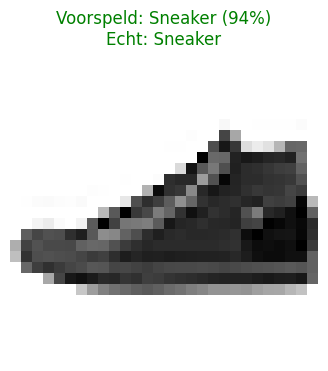

(4506, 'Sneaker', 'Sneaker', np.float32(94.06653))

In [67]:
def plot_random_prediction(model, images, true_labels, classes):
    # Kies willekeurig één afbeelding uit de meegegeven dataset
    index = random.randrange(len(images))
    image = images[index]
    true_label_index = true_labels[index]

    # Voeg een batch-dimensie toe, omdat model.predict() een batch verwacht
    # Shape gaat van (28, 28) naar (1, 28, 28)
    probabilities = model.predict(np.expand_dims(image, axis=0), verbose=0)[0]

    # Kies de klasse met de hoogste voorspelde kans
    predicted_label_index = np.argmax(probabilities)

    # Bereken hoe zeker het model is van deze voorspelling
    confidence = probabilities[predicted_label_index] * 100

    predicted_class = classes[predicted_label_index]
    true_class = classes[true_label_index]

    # Gebruik kleur om direct te tonen of de voorspelling goed of fout is
    title_color = "green" if predicted_label_index == true_label_index else "red"

    # Toon de afbeelding met voorspelde klasse, zekerheid en echte klasse
    plt.figure(figsize=(4, 4))
    plt.imshow(image, cmap=plt.cm.binary)
    plt.title(
        f"Voorspeld: {predicted_class} ({confidence:.0f}%)\nEcht: {true_class}",
        color=title_color
    )
    plt.axis("off")
    plt.show()

    return index, predicted_class, true_class, confidence


# Toon één willekeurige voorspelling uit de testset
plot_random_prediction(model_with_normalization, test_images_norm, test_labels, class_names)